# EXERCISE 3

> 'wine_quality.csv' presents data on taste-testing 38 brands of Pinot Noir wine (the data were first reported in an article by Kwan, Kowalski, and Skogenboe in the Journal of Agricultural and Food Chemistry (1979, Vol. 27)).

> The response variable is y = quality, and we wish to find the 'best' regression equation that relates quality to the other five parameters. 

In [1]:
#Import the necessary libraries
import qdatoolkit as qda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
import statsmodels.api as sm

#Import the dataset
data = pd.read_csv('../Data/wine_quality.csv')

# Inspect the dataset
data.head()

,Clarity,Aroma,Body,Flavor,Oakiness,Quality
0,1.0,3.3,2.8,3.1,4.1,9.8
1,1.0,4.4,4.9,3.5,3.9,12.6
2,1.0,3.9,5.3,4.8,4.7,11.9
3,1.0,3.9,2.6,3.1,3.6,11.1
4,1.0,5.6,5.1,5.5,5.1,13.3


> Let's start by visualizing the data.

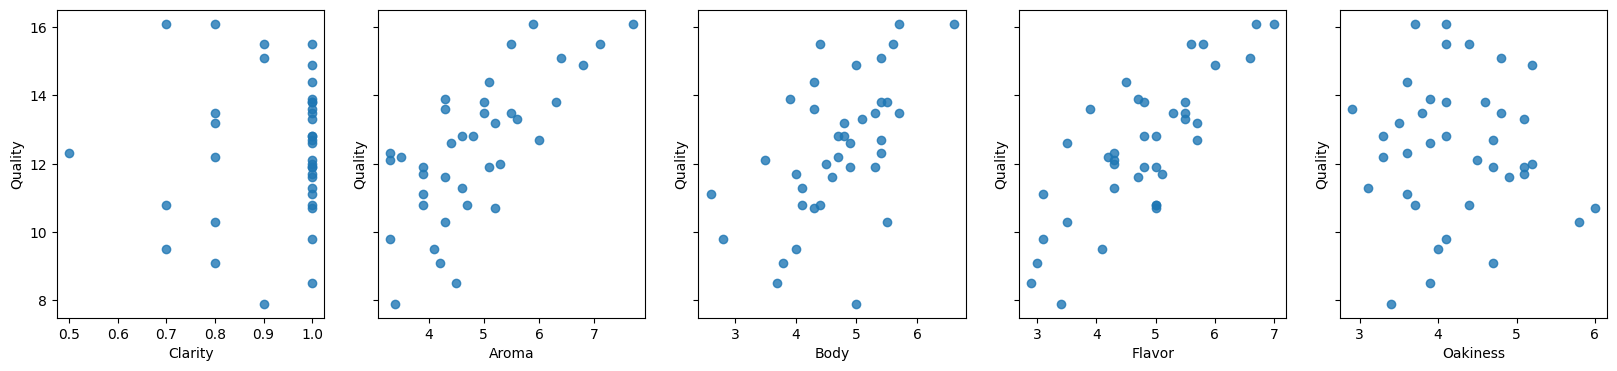

In [10]:
# Plot the data using pairplot in seaborn, Quality vs all other features
fig, ax = plt.subplots(1,5, figsize=(20, 4), sharey=True)
for i in range(5):
    ax[i].scatter(data.iloc[:, i],data['Quality'], alpha=0.8)
    ax[i].set_xlabel(data.columns[i])
    ax[i].set_ylabel('Quality')
plt.show()


> We notice that there are some indications of possible linear relationships between quality and the other variables.

> Let's exploit the bidirectional stepwise regression algorithm to identify the significant variables and, consequently, the best regression model.

In [3]:
# Fit the model 
X = data[['Clarity', 'Aroma', 'Body', 'Flavor', 'Oakiness']]
y = data['Quality']
X = sm.add_constant(X)  # Add a constant term to the predictor

# Create a Forward StepwiseRegression object using the qda library
stepwise = qda.StepwiseRegression(add_constant = True, direction = 'both', alpha_to_enter = 0.15, alpha_to_remove = 0.15)

# Fit the model
model = stepwise.fit(y, X)

Stepwise Regression

######################################
### Step 1
-------------------
Forward Selection

COEFFICIENTS
------------
 Term      Coef      P-Value
const 12.436842 4.912447e-31

MODEL SUMMARY
-------------
       S  R-sq  R-sq(adj)
2.045353   0.0        0.0
Backward Elimination

No predictor removed.

######################################
### Step 2
-------------------
Forward Selection

COEFFICIENTS
------------
  Term     Coef      P-Value
 const 4.941408 1.567960e-05
Flavor 1.571890 3.683253e-09

MODEL SUMMARY
-------------
       S     R-sq  R-sq(adj)
1.271192 0.624174   0.613735
Backward Elimination

No predictor removed.

######################################
### Step 3
-------------------
Forward Selection

COEFFICIENTS
------------
    Term      Coef      P-Value
   const  6.912198 1.721336e-05
  Flavor  1.641766 1.008998e-09
Oakiness -0.541444 5.883254e-02

MODEL SUMMARY
-------------
       S     R-sq  R-sq(adj)
1.224231 0.661112   0.641747
Backward Elimina

In [4]:
# Print the summary of the model
model = model.model_fit
qda.summary(model)

REGRESSION EQUATION
-------------------
Quality =  + 6.467 const + 1.200 Flavor -0.602 Oakiness + 0.580 Aroma

COEFFICIENTS
------------
    Term    Coef  SE Coef  T-Value    P-Value
   const  6.4672   1.3328   4.8524 2.6667e-05
  Flavor  1.1997   0.2749   4.3644 1.1265e-04
Oakiness -0.6023   0.2644  -2.2781 2.9127e-02
   Aroma  0.5801   0.2622   2.2126 3.3740e-02

MODEL SUMMARY
-------------
     S   R-sq  R-sq(adj)
1.1613 0.7038     0.6776

ANALYSIS OF VARIANCE
---------------------
    Source   DF   Adj SS  Adj MS  F-Value    P-Value
Regression  3.0 108.9350 36.3117  26.9249 4.2029e-09
     const  1.0  31.7543 31.7543  23.5456 2.6667e-05
    Flavor  1.0  25.6888 25.6888  19.0481 1.1265e-04
  Oakiness  1.0   6.9989  6.9989   5.1896 2.9127e-02
     Aroma  1.0   6.6026  6.6026   4.8958 3.3740e-02
     Error 34.0  45.8534  1.3486      NaN        NaN
     Total 37.0 154.7884     NaN      NaN        NaN


> Notice that the variables were entered in the order flavor (step 1), oakiness (step 2), and aroma (step 3) and that no variables were removed. No other variable could be entered, so the algorithm terminated. 

> Let's check assumptions on residuals.

In [5]:
# Get the residuals
residuals = model.resid

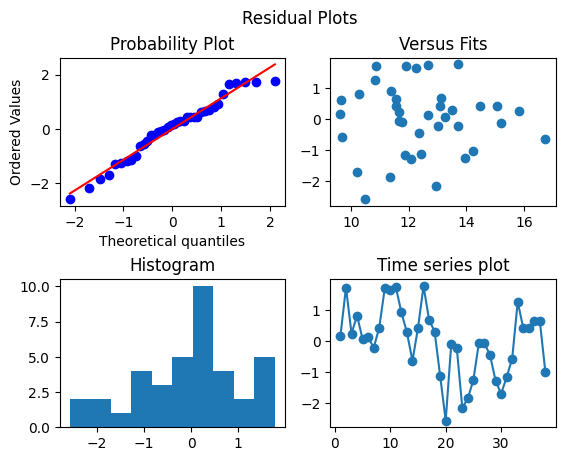

In [6]:
#NORMALITY OF RESIDUALS
fig, axs = plt.subplots(2, 2)
fig.suptitle('Residual Plots')

axs[0,0].set_title('Normal probability plot')
stats.probplot(residuals, dist="norm", plot=axs[0,0])

axs[0,1].set_title('Versus Fits')
axs[0,1].scatter(model.fittedvalues, residuals)

fig.subplots_adjust(hspace=0.5)

axs[1,0].set_title('Histogram')
axs[1,0].hist(residuals)

axs[1,1].set_title('Time series plot')
axs[1,1].plot(np.arange(1, len(residuals)+1), residuals, 'o-')
plt.show()